In [53]:
# ===== BƯỚC 1: NẠP THƯ VIỆN =====
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import random

In [44]:
# ===== BƯỚC 2: ĐỌC DỮ LIỆU CIFAR10 =====
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Shape X_train:", X_train.shape)   # (50000, 32, 32, 3)
print("Shape X_test :", X_test.shape)    # (10000, 32, 32, 3)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

# Tên nhãn để dễ đọc kết quả
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Shape X_train: (50000, 32, 32, 3)
Shape X_test : (10000, 32, 32, 3)
Shape y_train: (50000, 1)
Shape y_test : (10000, 1)


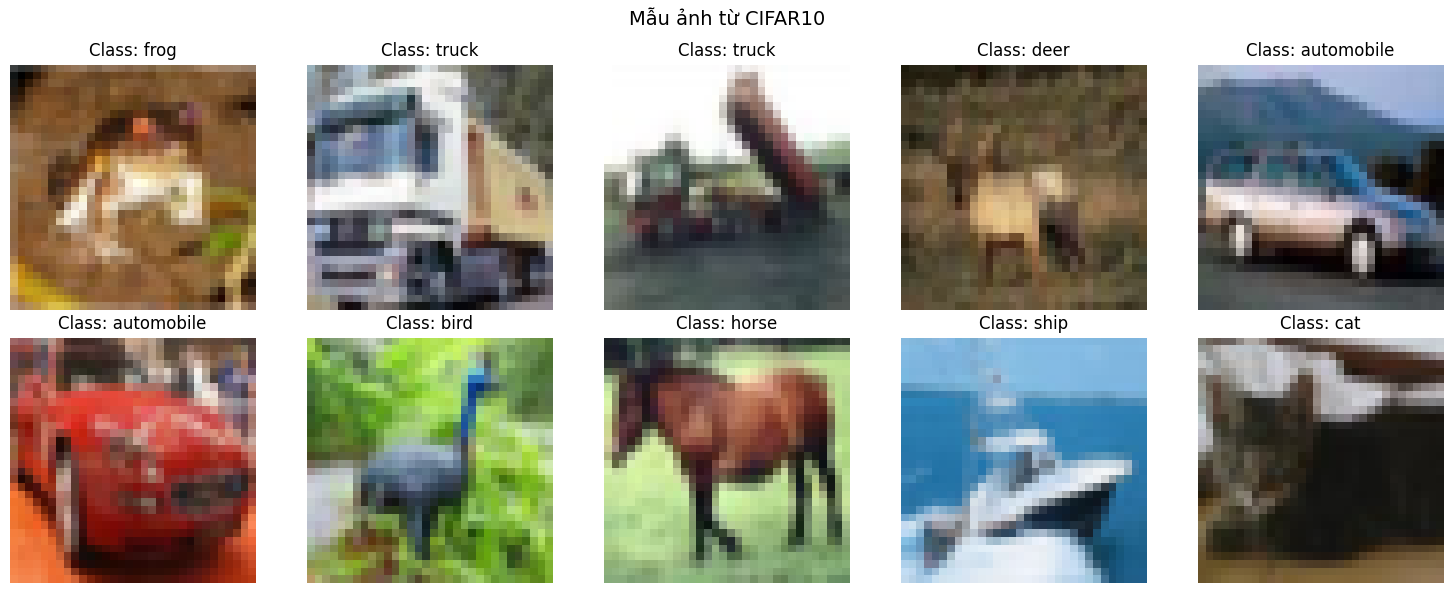

In [45]:
# ===== BƯỚC 3: TRỰC QUAN HÓA =====
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"Class: {class_names[y_train[i][0]]}")
    axes[i].axis('off')

plt.suptitle("Mẫu ảnh từ CIFAR10", fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# ===== BƯỚC 4: XỬ LÝ DỮ LIỆU =====

# CIFAR10 ảnh 32x32x3 => flatten thành vector 3072 chiều
X_train_flat = X_train.reshape(50000, 32 * 32 * 3).astype('float32')
X_test_flat  = X_test.reshape(10000, 32 * 32 * 3).astype('float32')

# Chuẩn hóa về [0, 1] bằng MinMaxScaler
# (hoặc đơn giản chia 255.0 — kết quả tương đương vì pixel đã trong [0,255])
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

# y_train hiện shape (50000,1) => squeeze thành (50000,)
y_train = y_train.flatten()
y_test  = y_test.flatten()

print("X_train sau reshape:", X_train_flat.shape)
print("Số lớp:", len(np.unique(y_train)))
print("Các lớp:", np.unique(y_train))

X_train sau reshape: (50000, 3072)
Số lớp: 10
Các lớp: [0 1 2 3 4 5 6 7 8 9]


In [47]:
# ===== BƯỚC 5: XÂY DỰNG MÔ HÌNH ANN =====
model = Sequential()

# Hidden layer 1
model.add(Dense(units=512,
                input_dim=X_train_flat.shape[1],   # 3072
                kernel_initializer='uniform',
                activation='relu'))
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(units=256,
                kernel_initializer='uniform',
                activation='relu'))
model.add(Dropout(0.3))

# Hidden layer 3
model.add(Dense(units=128,
                kernel_initializer='uniform',
                activation='relu'))

# Output layer — 10 lớp dùng softmax
model.add(Dense(units=10,
                kernel_initializer='uniform',
                activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# ===== BƯỚC 6: HUẤN LUYỆN =====
model_fit = model.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.2762 - loss: 1.9633 - val_accuracy: 0.3358 - val_loss: 1.8244
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3454 - loss: 1.8132 - val_accuracy: 0.3774 - val_loss: 1.7369
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3710 - loss: 1.7537 - val_accuracy: 0.3874 - val_loss: 1.7127
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3809 - loss: 1.7261 - val_accuracy: 0.3960 - val_loss: 1.6674
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.3892 - loss: 1.6978 - val_accuracy: 0.4158 - val_loss: 1.6252
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.4015 - loss: 1.6688 - val_accuracy: 0.4324 - val_loss: 1.6093
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4052 - loss: 1.6513 - val_accuracy: 0.4354 - val_loss: 1.6029
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4110 - loss: 1.6328 - 

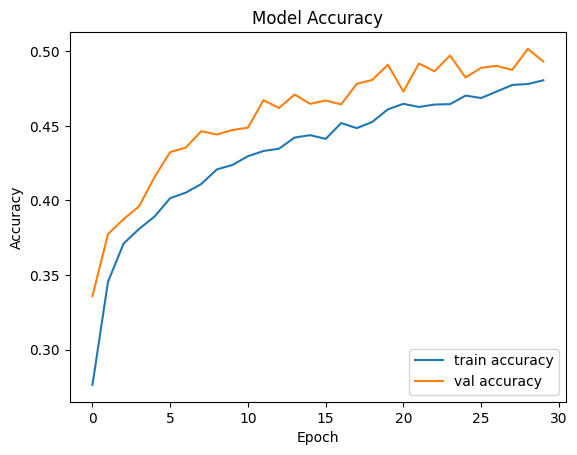

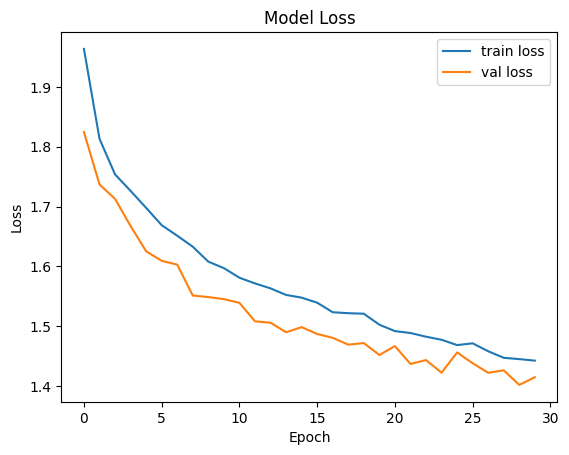


Test accuracy: 0.4977
Test loss    : 1.4153


In [49]:
# ===== BƯỚC 7: ĐÁNH GIÁ =====

# Vẽ accuracy
plt.plot(model_fit.history['accuracy'],    label='train accuracy')
plt.plot(model_fit.history['val_accuracy'],label='val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Vẽ loss
plt.plot(model_fit.history['loss'],    label='train loss')
plt.plot(model_fit.history['val_loss'],label='val loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

# Đánh giá trên tập test
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss    : {test_loss:.4f}")

In [50]:
# ===== BƯỚC 8: DỰ BÁO =====

# Dự báo toàn bộ tập test
y_pred = np.argmax(model.predict(X_test_flat), axis=1)

# Xem vài mẫu cụ thể
for idx in [0, 10, 100]:
    print(f"Index {idx:3d} — Predicted: {class_names[y_pred[idx]]:<12} | Actual: {class_names[y_test[idx]]}")

# Classification report đầy đủ
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Index   0 — Predicted: cat          | Actual: cat
Index  10 — Predicted: airplane     | Actual: airplane
Index 100 — Predicted: horse        | Actual: deer

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.53      0.62      0.57      1000
  automobile       0.60      0.62      0.61      1000
        bird       0.36      0.34      0.35      1000
         cat       0.35      0.34      0.34      1000
        deer       0.42      0.42      0.42      1000
         dog       0.44      0.33      0.37      1000
        frog       0.51      0.57      0.54      1000
       horse       0.55      0.55      0.55      1000
        ship       0.62      0.62      0.62      1000
       truck       0.56      0.58      0.57      1000

    accuracy                           0.50     10000
   macro avg       0.49      0.50      0.49     10000
weighted avg       0.49      0.50      0.49     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


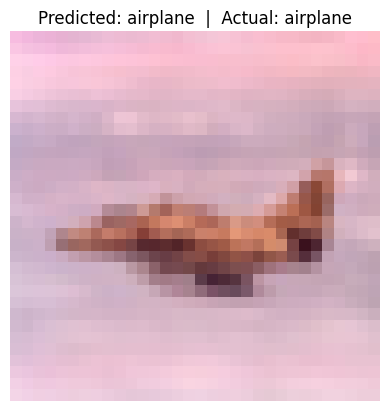

In [55]:
# ===== BƯỚC 9: DỰ BÁO 1 ẢNH BẤT KỲ =====
idx = random.randint(0, len(X_test)-1)  # Chọn ngẫu nhiên một ảnh từ tập test
img = X_test[idx]
img_flat = X_test_flat[idx].reshape(1, -1)

pred_probs = model.predict(img_flat)
pred_label = np.argmax(pred_probs)

plt.imshow(img)
plt.title(f"Predicted: {class_names[pred_label]}  |  Actual: {class_names[y_test[idx]]}")
plt.axis('off')
plt.show()